### Analyses of Pairwise Comparison for classification
- Read F1 scores
- Read inference files for in-depth analyses

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix
from IPython.display import Markdown, display
import numpy as np
from datasets import load_from_disk

In [2]:
# Inspect the dataset
# ds = load_from_disk("datasets/elsa_fulltext_SFT_gemma_3sh/elsa_fulltext_SFT_gemma_3sh.dataset")
# ds["train"][0]["gemmaprompt"]

In [3]:
# filter = "finetuned/gemma2-9b_SFT-elsa_bs1/"
filter = 13059602 # første gemma SFT med gemma2-9b_SFT-elsa_bs1
filter = 13681468 
ts_filter = '202510081919' # SFT-elsa-fulltext-0shot-5e4_gemma-2-2b-it_bs1-ep16-r16-a32-s101 , max w_avg is 0.619825
ts_filter = '202510172119' # SFT-elsa-fulltext-0shot-1e4_gemma-2-9b-it_bs1-ep24-r128-a256-s301
# Fire siste lr- testene med både dev og test
ts_filter = '202510191409'

def extract_train_step_int(train_step):
    ts = -100
    if  train_step == "final": ts = 1999
    elif train_step == "init_lora": ts = 2
    elif train_step == "not_finetuned": ts = 0
    elif "checkpoint" in train_step: ts = int(train_step.split("-")[-1])
    return ts


with open("sft_f1_scores.txt", "r") as f:
    f1_data = [json.loads(line.strip()) for line in f if line.strip()]
# f1_data = [record for record in f1_data if record.get("model_path").startswith(filter)]
filtered = [record for record in f1_data if int(record.get("slurm_job")) == filter]
# filtered = [record for record in f1_data if record.get("timestamp") == ts_filter]
print(len(filtered))
f1_df = pd.DataFrame.from_records(filtered)
f1_df['train_step_int'] = f1_df['train_step'].apply(extract_train_step_int)
f1_df["experiment"] = f1_df["model_path"].apply(lambda x: x.split("/")[1])
display(f1_df.eval_split.value_counts())


44


eval_split
dev     22
test    22
Name: count, dtype: int64

In [4]:
f1_df.sort_values("weighted_avg").tail(3)

,Negativt,Nøytralt,Positivt,weighted_avg,timestamp,model_path,train_step,eval_split,slurm_job,train_step_int,experiment
24,0.611111,0.864865,0.864322,0.843084,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-2385,test,13681468,2385,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
30,0.571429,0.871795,0.870968,0.845943,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-10494,test,13681468,10494,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
41,0.722222,0.872587,0.864322,0.856657,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-4770,test,13681468,4770,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...


SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_bs1-ep22-r128-a256-s305 44


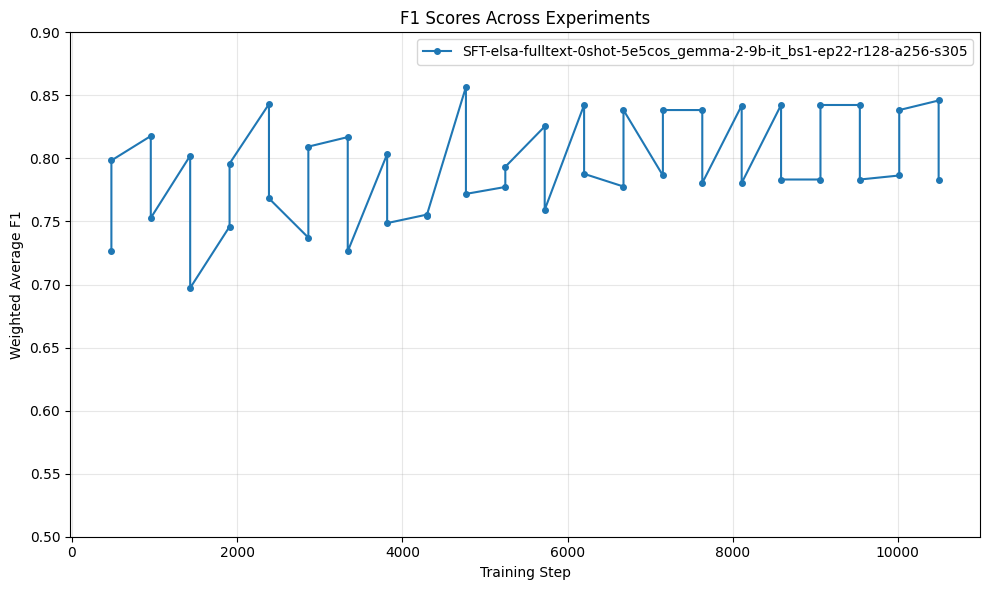

In [5]:

plt.figure(figsize=(10, 6))

# Sort the dataframe first
f1_df_sorted = f1_df.sort_values("train_step_int")

# Plot each experiment as a separate line on the same axes
for name, group in f1_df_sorted.groupby("experiment"):
    # Check if the current experiment is the one to be highlighted
    if name == "gemma2-9b_SFT-elsa_bs2": # I did a mistake in the arguments passed to training script. Was 1e-4 on  both.
        # Plot with a thicker line
        plt.plot(group['train_step_int'], group['weighted_avg'], label=name, marker='o', markersize=4, linewidth=3, zorder=0)
    else:
        # Plot other experiments normally
        plt.plot(group['train_step_int'], group['weighted_avg'], label=name, marker='o', markersize=4)

        
    print(name, len(group))

plt.xlabel('Training Step')
plt.ylabel('Weighted Average F1')
plt.ylim(0.5,0.9)
plt.title('F1 Scores Across Experiments')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_30654/3971942291.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(experiments))


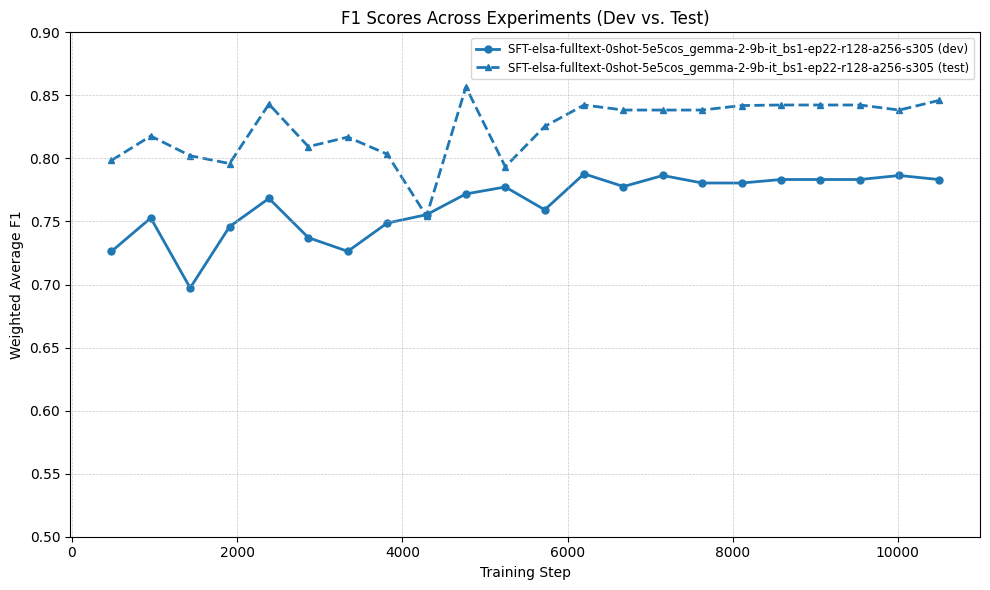

In [6]:

plt.figure(figsize=(10, 6))

# Sort the dataframe by step for correct line plotting
f1_df_sorted = f1_df.sort_values("train_step_int")

# Get unique experiment names to assign a consistent color to each
experiments = f1_df_sorted['experiment'].unique()
# Create a color map for the experiments
colors = plt.cm.get_cmap('tab10', len(experiments))

for i, name in enumerate(experiments):
    # Isolate all data for the current experiment
    exp_group = f1_df_sorted[f1_df_sorted['experiment'] == name]
    color = colors(i)

    # Check if this is the experiment to highlight
    is_highlighted = (name == "gemma2-9b_SFT-elsa_bs2")
    linewidth = 3 if is_highlighted else 2
    zorder = 5 if is_highlighted else 1 # Draw highlighted line on top

    # --- Plot 'dev' split data ---
    dev_data = exp_group[exp_group['eval_split'] == 'dev']
    if not dev_data.empty:
        plt.plot(dev_data['train_step_int'],
                 dev_data['weighted_avg'],
                 label=f"{name} (dev)",
                 marker='o',  # Circle marker for dev
                 markersize=5,
                 color=color,
                 linestyle='-', # Solid line for dev
                 linewidth=linewidth,
                 zorder=zorder)

    # --- Plot 'test' split data ---
    test_data = exp_group[exp_group['eval_split'] == 'test']
    if not test_data.empty:
        plt.plot(test_data['train_step_int'],
                 test_data['weighted_avg'],
                 label=f"{name} (test)",
                 marker='^',  # Triangle marker for test
                 markersize=5,
                 color=color,
                 linestyle='--', # Dashed line for test
                 linewidth=linewidth,
                 zorder=zorder)

plt.xlabel('Training Step')
plt.ylabel('Weighted Average F1')
plt.ylim(0.5, 0.9)
plt.title('F1 Scores Across Experiments (Dev vs. Test)')
plt.legend(loc='best', fontsize='small')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()



### Out of a group of experiments, make a table with the best dev result, its step and corresponding test result

In [11]:
def extract_train_step_int(train_step):
    ts = -100
    if  train_step == "final": ts = 1999
    elif train_step == "init_lora": ts = 2
    elif train_step == "not_finetuned": ts = 0
    elif "checkpoint" in train_step: ts = int(train_step.split("-")[-1])
    return ts

slurms = [13681468, 13681454, 13681395, 
          13681387
          ] # last four lr search experiments. 13681454 was the best
slurms = [13681454] # ONly the best of the four lr hyperp search values
slurms = [13786399, 13786402,  13786414] # ELSA ent2ent
slurms = [13681454, 13780843, 13780846] # ELSA fulltext
slurms = [ 13850900 ,13850901  ,  13850902 ]  # ELSA rel_sents
slurms = [13850923  , 13850924 ,  13850950] # ELSA rel_span


with open("sft_f1_scores.txt", "r") as f:
    f1_data = [json.loads(line.strip()) for line in f if line.strip()]

records = []
for slurm in slurms:
    filtered = [record for record in f1_data if int(record.get("slurm_job")) == slurm]
    # filtered = [record for record in f1_data if record.get("timestamp") == ts_filter]
    # print(len(filtered))
    devtest = pd.DataFrame.from_records(filtered)
    devtest['train_step_int'] = devtest['train_step'].apply(extract_train_step_int)
    devtest["experiment"] = devtest["model_path"].apply(lambda x: x.split("/")[1])
    print(devtest.eval_split.value_counts().to_dict())
    dev_best_i = devtest[devtest.eval_split == "dev"]["weighted_avg"].idxmax()
    dev_best_step = devtest.loc[dev_best_i, "train_step_int"]
    best_test = devtest.query('eval_split == "test" and train_step_int == @dev_best_step').iloc[0]
    # print(slurm, devtest.loc[dev_best_i, "train_step_int"], devtest.loc[dev_best_i, "weighted_avg"] )
    records.append(dict(
        slurm = slurm,
        dev_best_step = dev_best_step,
        dev_wf1 = devtest.loc[dev_best_i, "weighted_avg"] ,
        test_wf1 = best_test["weighted_avg"]
    ))

records
dev_best = pd.DataFrame.from_records(records)
dev_best.sort_values("dev_wf1")

# For three seeds of same experiment
for r in records:
    print(r)
testresults = [r["test_wf1"] for r in records]
print("\nMean and st dev on test for best dev epoch", round(np.mean(testresults)*100,2), round(np.std(testresults)*100,1))

# Get training times. Did not use this. Used real from slurm script since that is what I had on the old experiments
records = []
with open("sft_logging.txt", "r") as f:
    f1_meta = [json.loads(line.strip()) for line in f if line.strip()]
for slurm in slurms:
    filtered = [record for record in f1_meta if int(record.get("slurm_id")) == slurm]

    dev_meta = pd.DataFrame.from_records(filtered)
    train_time = dev_meta.seconds_since_trainstart.max()
    records.append(dict(
        train_time = train_time,
    ))
sft_ent2ent_minutes = [684, 688, 688]
print("ent2ent minutes trainscript",int(np.mean(sft_ent2ent_minutes)))
fulltext_minutes = [1582, 1608, 1633]
print("fulltext minutes trainscript",int(np.mean(fulltext_minutes)))

{'dev': 22, 'test': 22}
{'dev': 22, 'test': 22}
{'dev': 22, 'test': 22}
{'slurm': 13850923, 'dev_best_step': 2862, 'dev_wf1': 0.7382426591766099, 'test_wf1': 0.7531356424570742}
{'slurm': 13850924, 'dev_best_step': 4770, 'dev_wf1': 0.7471334908214898, 'test_wf1': 0.7544706998793386}
{'slurm': 13850950, 'dev_best_step': 1431, 'dev_wf1': 0.7490978881316823, 'test_wf1': 0.7880278313018251}

Mean and st dev on test for best dev epoch 76.52 1.6
ent2ent minutes trainscript 686
fulltext minutes trainscript 1607


In [8]:
records


[{'train_time': 35638}, {'train_time': 35446}, {'train_time': 35155}]

In [9]:
f1_df.sort_values("weighted_avg", ascending=False)

,Negativt,Nøytralt,Positivt,weighted_avg,timestamp,model_path,train_step,eval_split,slurm_job,train_step_int,experiment
41,0.722222,0.872587,0.864322,0.856657,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-4770,test,13681468,4770,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
30,0.571429,0.871795,0.870968,0.845943,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-10494,test,13681468,10494,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
24,0.611111,0.864865,0.864322,0.843084,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-2385,test,13681468,2385,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
25,0.555556,0.867647,0.870968,0.842377,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-9540,test,13681468,9540,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
43,0.555556,0.867647,0.870968,0.842377,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-8586,test,13681468,8586,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
33,0.555556,0.867647,0.870968,0.842377,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-9063,test,13681468,9063,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
35,0.555556,0.866667,0.872340,0.842375,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-6201,test,13681468,6201,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
31,0.571429,0.867647,0.866310,0.841954,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-8109,test,13681468,8109,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
29,0.555556,0.863469,0.866310,0.838371,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-6678,test,13681468,6678,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
39,0.555556,0.863469,0.866310,0.838371,202510191523,finetuned/SFT-elsa-fulltext-0shot-5e5cos_gemma...,checkpoint-7632,test,13681468,7632,SFT-elsa-fulltext-0shot-5e5cos_gemma-2-9b-it_b...
